# Fase 3: Núcleo algorítmico, eficiencia y programación orientada a objetos

## Obtención y preparación de datos

Aunque durante la Fase 2 se generó un dataset procesado, en esta fase se implementó un pipeline completo capaz de reconstruir el proceso de preparación a partir de los archivos originales del WFP. De esta forma, la carga, consolidación, transformación y validación quedan encapsuladas dentro de una arquitectura orientada a objetos reproducible.

In [1]:
# Agrega la carpeta src al path de Python para permitir
# importar los módulos desarrollados para la Fase 3.

from pathlib import Path
import sys

sys.path.append("../src")

In [2]:
from preprocesador import Preprocesador

preprocesador = Preprocesador("../../F1/data/raw")

df = (
    preprocesador
    .cargar_archivos()
    .validar_columnas_requeridas()
    .filtrar_europa()
    .convertir_fechas()
    .eliminar_nulos_usdprice()
    .normalizar_usdprice()
    .validar()
    .obtener_dataframe()
)

  Cargado: wfp_food_prices_global_2020.csv (424,766 filas)
  Cargado: wfp_food_prices_global_2021.csv (494,805 filas)
  Cargado: wfp_food_prices_global_2022.csv (488,649 filas)
  Cargado: wfp_food_prices_global_2023.csv (484,110 filas)
  Cargado: wfp_food_prices_global_2024.csv (437,038 filas)
  Cargado: wfp_food_prices_global_2025.csv (419,527 filas)

Dataset consolidado: 2,748,895 filas, 18 columnas
Columnas requeridas verificadas: ['date', 'countryiso3', 'commodity', 'usdprice', 'market', 'category']
Filtrado geográfico: 2,748,895 → 73,506 filas (2,675,389 eliminadas)
Fechas convertidas. Rango: 2020 – 2025
Nulos eliminados en usdprice: 400 filas. Registros restantes: 73,106
Normalización z-score aplicada. Media: 1.7696, Desv. estándar: 2.0008
Validaciones superadas. Dataset final: 73,106 filas, 21 columnas.


In [3]:
# Muestra los primeros registros del dataset para
# verificar que la carga se realizó correctamente.

df.head()

,countryiso3,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,...,unit,priceflag,pricetype,currency,price,usdprice,archivo_origen,year,month,usdprice_zscore
42205,BLR,2020-01-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Bread (high grade flour),...,KG,actual,Retail,BYR,2.89,1.36,wfp_food_prices_global_2020.csv,2020,1,-0.204730
42206,BLR,2020-01-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Potatoes,...,KG,actual,Retail,BYR,0.84,0.40,wfp_food_prices_global_2020.csv,2020,1,-0.684544
42207,BLR,2020-01-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Wheat flour,...,KG,actual,Retail,BYR,1.28,0.60,wfp_food_prices_global_2020.csv,2020,1,-0.584583
42208,BLR,2020-02-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Bread (high grade flour),...,KG,actual,Retail,BYR,2.88,1.31,wfp_food_prices_global_2020.csv,2020,2,-0.229720
42209,BLR,2020-02-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Potatoes,...,KG,actual,Retail,BYR,0.83,0.38,wfp_food_prices_global_2020.csv,2020,2,-0.694540


## Validación técnica reproducible

Antes de iniciar el análisis, se ejecutan validaciones automáticas para verificar la integridad del dataset procesado. Estas comprobaciones permiten confirmar la ausencia de duplicados, la disponibilidad de precios en USD y la consistencia temporal de los registros utilizados durante la Fase 3.

In [4]:
# Validaciones formales del dataset.

assert not df.empty, "El DataFrame está vacío."
assert df.duplicated().sum() == 0, "Existen registros duplicados."
assert df["usdprice"].isna().sum() == 0, "Existen valores nulos en usdprice."
assert df["year"].between(2020, 2025).all(), "Existen años fuera del rango esperado."
assert "usdprice_zscore" in df.columns, "Falta la columna usdprice_zscore."
assert "archivo_origen" in df.columns, "Falta la columna archivo_origen."

print("Todas las validaciones fueron superadas correctamente.")
print(f"  Filas: {len(df):,}")
print(f"  Columnas: {df.shape[1]}")
print(f"  Países únicos: {df['countryiso3'].nunique()}")

Todas las validaciones fueron superadas correctamente.
  Filas: 73,106
  Columnas: 21
  Países únicos: 5


In [5]:
# Caso límite: carpeta inexistente.

try:
    Preprocesador("ruta/que/no/existe").cargar_archivos()
except FileNotFoundError as error:
    print(f"FileNotFoundError capturada correctamente: {error}")



FileNotFoundError capturada correctamente: La carpeta no existe: ruta\que\no\existe


In [6]:
# Caso límite:búsqueda de un país inexistente.

df_pais_inexistente = df[df["countryiso3"] == "XXX"]
assert df_pais_inexistente.empty, "No debería haber registros para 'XXX'."
print("Caso límite validado correctamente.")

Caso límite validado correctamente.


## Cálculo de precios promedio anuales

Como parte del núcleo algorítmico de la Fase 3, se implementó una clase orientada a objetos responsable de calcular la evolución anual de los precios de los productos alimentarios.

La estrategia consiste en agrupar los registros por producto y año, obteniendo un precio promedio anual que permita comparar distintos períodos de manera homogénea.

Posteriormente, se calcula la variación porcentual año a año para identificar tendencias de crecimiento o disminución de precios dentro del período de estudio.

In [7]:
from analizador import AnalizadorVariacionPrecios

In [8]:
# Crea una instancia del analizador y calcula
# los precios promedio anuales.

analizador = AnalizadorVariacionPrecios(df)

df_promedios = (
    analizador
    .calcular_precios_promedio_anuales()
)

df_promedios.head()

,commodity,year,precio_promedio
0,Antibiotics (imported),2020,4.106881
1,Antibiotics (imported),2021,4.201246
2,Antibiotics (imported),2022,5.422264
3,Antibiotics (imported),2023,5.174925
4,Antibiotics (imported),2024,5.437749


In [9]:
# Calcula la variación porcentual año a año
# para cada producto.

df_variaciones = (
    analizador
    .calcular_variaciones_anuales()
)

df_variaciones.head(20)

,commodity,year,precio_promedio,variacion_pct
0,Antibiotics (imported),2020,4.106881,NaN
1,Antibiotics (imported),2021,4.201246,2.297715
2,Antibiotics (imported),2022,5.422264,29.063245
3,Antibiotics (imported),2023,5.174925,-4.561541
4,Antibiotics (imported),2024,5.437749,5.078792
5,Antibiotics (imported),2025,6.883358,26.584687
6,Antibiotics (local),2020,0.682363,NaN
7,Antibiotics (local),2021,0.721541,5.741531
8,Antibiotics (local),2022,1.227248,70.087064
9,Antibiotics (local),2023,1.302432,6.126257


## Identificación de variaciones extremas

Una vez calculadas las variaciones porcentuales anuales, se identifican los productos que registraron los mayores aumentos y las mayores disminuciones de precio. Esta información permite detectar comportamientos relevantes dentro del conjunto de datos y proporciona evidencia para el análisis posterior.

In [10]:
# Muestra los productos con mayor aumento
# porcentual de precio.

df_variaciones.sort_values(
    by="variacion_pct",
    ascending=False
).head(10)

,commodity,year,precio_promedio,variacion_pct
112,Cabbage,2022,0.701232,156.548250
363,Onions,2022,0.704462,121.777545
463,Vasodilating agents (imported),2024,1.869891,106.741841
118,Carrots,2022,0.701190,96.601930
164,Cucumbers,2022,1.240938,92.617385
468,Vasodilating agents (local),2023,1.359735,85.740631
29,Apples,2025,1.237320,83.387635
176,Eggplants,2022,1.275000,74.110953
443,Tomatoes,2022,1.151481,72.907480
387,Potatoes,2024,0.588198,72.871809


In [11]:
# Muestra los productos con mayor disminución
# porcentual de precio.

df_variaciones.sort_values(
    by="variacion_pct",
    ascending=True
).head(10)

,commodity,year,precio_promedio,variacion_pct
469,Vasodilating agents (local),2024,0.410704,-69.795309
365,Onions,2024,0.438929,-50.800800
120,Carrots,2024,0.480858,-49.657534
248,Garlic,2022,1.680000,-47.615788
55,Beetroots,2023,0.348587,-45.134483
96,Buckwheat,2024,0.739364,-45.116143
462,Vasodilating agents (imported),2023,0.904457,-42.477729
95,Buckwheat,2023,1.347143,-40.312479
247,Garlic,2021,3.207073,-39.870510
32,Bananas,2022,1.047083,-37.518647


In [12]:
# Muestra la evolución anual del pan para
# verificar que el cálculo es correcto.

df_variaciones[
    df_variaciones["commodity"]
    == "Bread (high grade flour)"
    ]

,commodity,year,precio_promedio,variacion_pct
74,Bread (high grade flour),2020,0.919805,NaN
75,Bread (high grade flour),2021,1.063344,15.605445
76,Bread (high grade flour),2022,1.138556,7.073100
77,Bread (high grade flour),2023,1.100530,-3.339780
78,Bread (high grade flour),2024,1.140481,3.630175
79,Bread (high grade flour),2025,1.340292,17.519836


In [13]:
# Importa el algoritmo recursivo Merge Sort.

from algoritmos import merge_sort

In [14]:
# Casos límite del algoritmo merge_sort.

assert merge_sort([]) == [], "Falla: lista vacía."
assert merge_sort([10]) == [10], "Falla: un elemento."
assert merge_sort([1, 2, 3]) == [1, 2, 3], "Falla: ya ordenada."
assert merge_sort([3, 2, 1]) == [1, 2, 3], "Falla: orden inverso."
assert merge_sort([-1, 5, 0, -3]) == [-3, -1, 0, 5], "Falla: negativos."
assert merge_sort([4, 2, 4, 1]) == [1, 2, 4, 4], "Falla: duplicados."

print("Todos los casos límite de merge_sort superados correctamente.")

Todos los casos límite de merge_sort superados correctamente.


In [15]:
# Genera una lista de ejemplo con las variaciones
# porcentuales calculadas previamente.

variaciones = (
    df_variaciones["variacion_pct"]
    .dropna()
    .tolist()
)

print("Cantidad de variaciones:", len(variaciones))

Cantidad de variaciones: 412


In [16]:
# Ordena las variaciones utilizando
# el algoritmo Merge Sort.

variaciones_ordenadas = merge_sort(
    variaciones
)

variaciones_ordenadas[:20]

[-69.79530941923342,
 -50.80079998962736,
 -49.65753424657534,
 -47.615788272872464,
 -45.13448306115031,
 -45.11614312640283,
 -42.47772855033109,
 -40.312479179159176,
 -39.87050979306209,
 -37.51864743908503,
 -34.069097888675614,
 -32.545445994583254,
 -29.659260579858714,
 -28.609211126310996,
 -28.48885218827415,
 -27.986590445535274,
 -27.646156468382486,
 -27.147671483144354,
 -26.850062263747333,
 -24.678254679414135]

In [17]:
# Importa las herramientas necesarias para medir
# el tiempo de ejecución de los algoritmos.

import timeit

In [18]:
# Mide el tiempo de ejecución del algoritmo
# Merge Sort implementado de forma recursiva.

tiempo_merge_sort = timeit.timeit(
    lambda: merge_sort(variaciones.copy()),
    number=100
)

print(
    f"Tiempo Merge Sort: "
    f"{tiempo_merge_sort:.6f} segundos"
)

Tiempo Merge Sort: 0.058511 segundos


In [19]:
# Mide el tiempo de ejecución del algoritmo
# de ordenamiento nativo de Python.

tiempo_sorted = timeit.timeit(
    lambda: sorted(variaciones.copy()),
    number=100
)

print(
    f"Tiempo sorted(): "
    f"{tiempo_sorted:.6f} segundos"
)

Tiempo sorted(): 0.001288 segundos


In [20]:
# Resume los resultados obtenidos durante la
# medición de rendimiento.

print("Comparación de rendimiento")
print("-" * 40)

print(
    f"Merge Sort : "
    f"{tiempo_merge_sort:.6f} segundos"
)

print(
    f"sorted()   : "
    f"{tiempo_sorted:.6f} segundos"
)

if tiempo_merge_sort < tiempo_sorted:
    print(
        "\nMerge Sort fue más rápido."
    )
else:
    print(
        "\nsorted() fue más rápido."
    )

Comparación de rendimiento
----------------------------------------
Merge Sort : 0.058511 segundos
sorted()   : 0.001288 segundos

sorted() fue más rápido.


## Medición de eficiencia algorítmica

Como parte del análisis de eficiencia exigido en la Fase 3, se comparó el rendimiento del algoritmo Merge Sort implementado de forma recursiva con el algoritmo de ordenamiento nativo de Python (`sorted()`).

Las mediciones fueron realizadas utilizando la librería `timeit`, ejecutando múltiples iteraciones sobre el mismo conjunto de datos con el objetivo de obtener resultados reproducibles y comparables.

Esta evaluación permitirá justificar posteriormente la elección de las estructuras y algoritmos utilizados dentro del proyecto, considerando criterios de complejidad temporal y eficiencia práctica.

## Escalamiento del algoritmo

Además de comparar una única ejecución, se evaluó el comportamiento de los algoritmos frente a distintos tamaños de entrada. Esta prueba permite observar cómo varía el tiempo de ejecución a medida que aumenta la cantidad de elementos a ordenar.

In [21]:
import random
import timeit
import pandas as pd
from algoritmos import merge_sort, insertion_sort

tamanos = [25, 50, 100, 200, 400, 800, 1600]
repeticiones = 200
random.seed(42)

resultados = []

for n in tamanos:
    datos = [random.uniform(-100, 100) for _ in range(n)]

    t_merge = timeit.timeit(lambda d=datos: merge_sort(d), number=repeticiones) / repeticiones
    t_insertion = timeit.timeit(lambda d=datos: insertion_sort(d), number=repeticiones) / repeticiones
    t_sorted = timeit.timeit(lambda d=datos: sorted(d), number=repeticiones) / repeticiones

    resultados.append({
        "n": n,
        "merge_sort (ms)": round(t_merge * 1000, 4),
        "insertion_sort (ms)": round(t_insertion * 1000, 4),
        "sorted() (ms)": round(t_sorted * 1000, 4),
    })

df_escalamiento = pd.DataFrame(resultados)
print(df_escalamiento.to_string(index=False))

   n  merge_sort (ms)  insertion_sort (ms)  sorted() (ms)
  25           0.0207               0.0089         0.0005
  50           0.0481               0.0355         0.0018
 100           0.1017               0.1233         0.0022
 200           0.2039               0.4280         0.0043
 400           0.4268               1.8063         0.0100
 800           0.9289               8.1683         0.0335
1600           2.0711              34.0217         0.0908


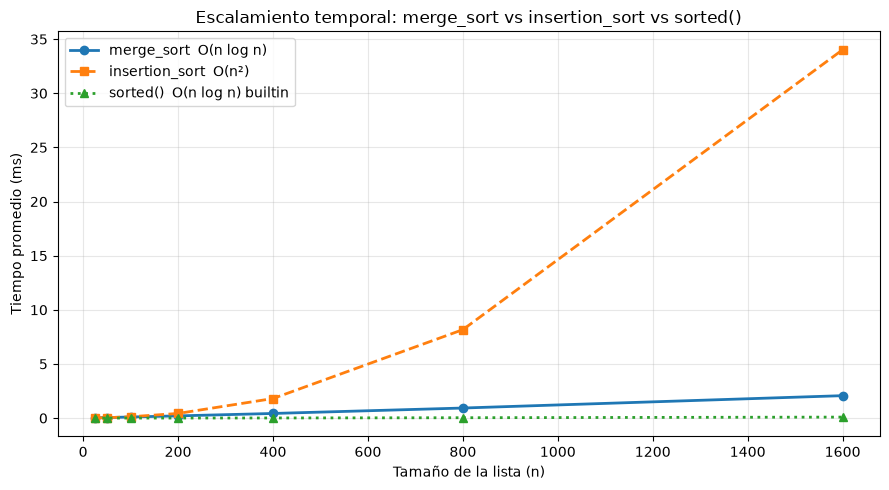

Gráfico guardado en F3/results/


In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df_escalamiento["n"], df_escalamiento["merge_sort (ms)"],
        marker="o", linewidth=2, label="merge_sort  O(n log n)")
ax.plot(df_escalamiento["n"], df_escalamiento["insertion_sort (ms)"],
        marker="s", linewidth=2, linestyle="--", label="insertion_sort  O(n²)")
ax.plot(df_escalamiento["n"], df_escalamiento["sorted() (ms)"],
        marker="^", linewidth=2, linestyle=":", label="sorted()  O(n log n) builtin")

ax.set_xlabel("Tamaño de la lista (n)")
ax.set_ylabel("Tiempo promedio (ms)")
ax.set_title("Escalamiento temporal: merge_sort vs insertion_sort vs sorted()")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/eficiencia_escalamiento.png", dpi=150)
plt.show()

print("Gráfico guardado en F3/results/")

### Interpretación


Los resultados evidencian que los tres algoritmos incrementan su tiempo de ejecución a medida que crece el tamaño de la entrada, pero a ritmos distintos que reflejan sus diferencias de complejidad.

`insertion_sort` presenta el crecimiento más pronunciado, coherente con su complejidad O(n²). Para entradas pequeñas (n ≤ 50) su rendimiento es comparable al de `merge_sort`, pero a partir de n = 200 la diferencia se vuelve visible y se amplía progresivamente con entradas mayores.

`merge_sort` mantiene un crecimiento más controlado, consistente con su complejidad O(n log n) en todos los casos. Sin embargo, al ser una implementación en Python puro incorpora costos adicionales por las llamadas recursivas, la creación de sublistas en cada nivel y el proceso de fusión. Esto explica que sea más lento que `sorted()` pese a compartir la misma complejidad teórica.

`sorted()` es significativamente más rápido en todos los tamaños evaluados. Aunque su complejidad teórica es también O(n log n), utiliza una implementación de Timsort escrita en C y optimizada para el intérprete de Python, lo que elimina el overhead que sí afecta a las implementaciones propias.

A partir de estas mediciones se concluye que `merge_sort` constituye una solución correcta para demostrar recursividad y análisis de complejidad con propósito académico, mientras que `sorted()` es la alternativa adecuada para aplicaciones reales. La comparación con `insertion_sort` permite además observar empíricamente la diferencia práctica entre complejidades O(n²) y O(n log n) a medida que n crece.

## Aplicación de herencia y polimorfismo

Como parte de la incorporación progresiva de principios de programación orientada a objetos, se implementó una clase base denominada `AnalizadorBase`, encargada de definir una interfaz común para los distintos tipos de análisis desarrollados en el proyecto.

A partir de esta clase se construyeron analizadores especializados mediante herencia, reutilizando atributos comunes y sobrescribiendo el método `analizar()` según el comportamiento requerido por cada implementación.

In [23]:
# Importa los analizadores implementados mediante
# herencia a partir de AnalizadorBase.

from analizador import (
    AnalizadorVariacionPrecios,
    AnalizadorEstadistico
)

In [24]:
# Analizador de variaciones de precios.

analizador_variacion = (
    AnalizadorVariacionPrecios(df)
)

resultado_variacion = (
    analizador_variacion.analizar()
)

resultado_variacion.head()

,commodity,year,precio_promedio,variacion_pct
0,Antibiotics (imported),2020,4.106881,NaN
1,Antibiotics (imported),2021,4.201246,2.297715
2,Antibiotics (imported),2022,5.422264,29.063245
3,Antibiotics (imported),2023,5.174925,-4.561541
4,Antibiotics (imported),2024,5.437749,5.078792


In [25]:
# Analizador estadístico.

analizador_estadistico = (
    AnalizadorEstadistico(df)
)

resultado_estadistico = (
    analizador_estadistico.analizar()
)

resultado_estadistico

count    73106.000000
mean         1.769619
std          2.000776
min          0.049000
25%          0.610000
50%          0.970000
75%          2.080000
max         25.090000
Name: usdprice, dtype: float64

In [26]:
# Demostración de polimorfismo.

analizadores = [
    AnalizadorVariacionPrecios(df),
    AnalizadorEstadistico(df)
]

for analizador in analizadores:

    print(
        f"\nClase: {analizador.__class__.__name__}"
    )

    resultado = analizador.analizar()

    print(type(resultado))


Clase: AnalizadorVariacionPrecios
<class 'pandas.DataFrame'>

Clase: AnalizadorEstadistico
<class 'pandas.Series'>


### Justificación de la arquitectura orientada a objetos

La separación en clases con responsabilidad única responde a decisiones de diseño concretas:

**¿Por qué `AnalizadorBase` define `analizar()` como método abstracto?**

Permite aplicar polimorfismo real: el código cliente puede iterar sobre cualquier lista de analizadores y ejecutar el mismo método sin conocer el tipo concreto de cada uno. Si en el futuro se agrega un nuevo tipo de análisis, basta con crear una nueva subclase sin modificar el código existente.

**¿Por qué los atributos son protegidos (`_df`, `_carpeta_raw`)?**

El encapsulamiento evita que el estado interno del objeto sea modificado accidentalmente desde fuera de la clase. Obliga a interactuar mediante los métodos definidos, lo que hace el comportamiento del objeto predecible y controlado.

**¿Qué trade-off implica usar POO frente a funciones simples?**

La POO agrega complejidad inicial: más archivos, más clases, más estructura. Para un análisis pequeño, funciones simples serían suficientes. Sin embargo, cuando el proyecto crece en número de análisis, fuentes de datos o tipos de preprocesamiento, la arquitectura orientada a objetos facilita la extensión sin romper el código existente.

## Implementación del pipeline de análisis

`PipelineAnalisis` coordina el flujo completo en una única interfaz. 

El código externo solo necesita conocer esta clase: no requiere instanciar `Preprocesador` ni los analizadores directamente. Esto reduce el acoplamiento entre componentes y centraliza el punto de entrada del análisis.

In [27]:
# Importa la clase responsable de coordinar
# el flujo completo de análisis.

from pipeline import PipelineAnalisis

In [28]:
# Ejecuta el pipeline completo.

pipeline = PipelineAnalisis("../../F1/data/raw")

variaciones, estadisticas = pipeline.ejecutar()

  Cargado: wfp_food_prices_global_2020.csv (424,766 filas)
  Cargado: wfp_food_prices_global_2021.csv (494,805 filas)
  Cargado: wfp_food_prices_global_2022.csv (488,649 filas)
  Cargado: wfp_food_prices_global_2023.csv (484,110 filas)
  Cargado: wfp_food_prices_global_2024.csv (437,038 filas)
  Cargado: wfp_food_prices_global_2025.csv (419,527 filas)

Dataset consolidado: 2,748,895 filas, 18 columnas
Columnas requeridas verificadas: ['date', 'countryiso3', 'commodity', 'usdprice', 'market', 'category']
Filtrado geográfico: 2,748,895 → 73,506 filas (2,675,389 eliminadas)
Fechas convertidas. Rango: 2020 – 2025
Nulos eliminados en usdprice: 400 filas. Registros restantes: 73,106
Normalización z-score aplicada. Media: 1.7696, Desv. estándar: 2.0008
Validaciones superadas. Dataset final: 73,106 filas, 21 columnas.


In [29]:
# Visualiza las variaciones calculadas.

variaciones.head()

,commodity,year,precio_promedio,variacion_pct
0,Antibiotics (imported),2020,4.106881,NaN
1,Antibiotics (imported),2021,4.201246,2.297715
2,Antibiotics (imported),2022,5.422264,29.063245
3,Antibiotics (imported),2023,5.174925,-4.561541
4,Antibiotics (imported),2024,5.437749,5.078792


In [30]:
# Visualiza las estadísticas descriptivas.

estadisticas

count    73106.000000
mean         1.769619
std          2.000776
min          0.049000
25%          0.610000
50%          0.970000
75%          2.080000
max         25.090000
Name: usdprice, dtype: float64